The ``aaanalysis.pipe`` (``aap``) module provides high-level **golden pipelines** — stateless, one-call wrappers over the AAanalysis primitives. ``aap.find_features`` runs a staged, interpretable **CPP AutoML** search: it sweeps the CPP feature space (which sequence Splits, which Part regions, which Scale breadth) together with the ``n_filter`` selection, scores every configuration by cross-validated model performance, selects a **robust** winner, refines it, ranks the features by tree-based importance, and draws the feature map. It returns the triple ``(df_feat, ax, df_eval)``.

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.pipe as aap

aa.options["verbose"] = False
aa.plot_settings()

df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

aa.display_df(df_seq, n_rows=10, show_shape=True)

DataFrame shape: (40, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,99,121,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,42,64,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,729,751,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,527,549,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,549,571,TVSPQTSQAG,VAVMAVAVSVGLLLLVVAVFYCV,RRKGGPCCRQ


**Fast mode** runs a single default configuration — no search. The result is byte-identical to writing the explicit CPP chain by hand. ``df_eval`` then holds one row (the single configuration with its cross-validated ``balanced_accuracy``):

In [2]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, optimization="fast",
                                         plot=False, random_state=42, n_jobs=1)

aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (1, 11)


,list_parts,split_types,pattern_mode,n_split_max,n_explain,n_filter,n_features,cv_bacc_mean,cv_bacc_std,rank,is_selected
1,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,30,100,81,0.950000,0.100000,1,True


**Balanced mode** sweeps the Split levers and ``n_filter`` over the default parts/scales, then selects the simplest configuration within 1% of the best cross-validated score. ``df_eval`` is the full per-configuration sweep table, ranked best-first; the chosen row is flagged ``is_selected``:

In [3]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, optimization="balanced",
                                         plot=False, random_state=42, n_jobs=1)

aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (48, 11)


,list_parts,split_types,pattern_mode,n_split_max,n_explain,n_filter,n_features,cv_bacc_mean,cv_bacc_std,rank,is_selected
1,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,50,150,150,1.000000,0.000000,1,False
2,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,50,125,125,1.000000,0.000000,2,False
3,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,50,125,125,1.000000,0.000000,3,False
4,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,50,100,100,1.000000,0.000000,4,True
5,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,50,150,150,1.000000,0.000000,5,False
6,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,50,125,125,1.000000,0.000000,6,False
7,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,10,50,100,100,0.975000,0.050000,7,False
8,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,10,50,50,50,0.975000,0.050000,8,False
9,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,10,50,75,75,0.975000,0.050000,9,False
10,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,10,50,150,150,0.975000,0.050000,10,False


The selection criterion is a cross-validated model: ``model`` (``"svm"`` / ``"rf"`` / ``"log_reg"``), ``cv`` folds, and the ``metric``. The bounded ``kws`` dict pins any single lever (here ``n_filter``), ``simplify`` toggles the refinement post-step, ``label_test`` / ``label_ref`` set the compared classes, and ``subcategories`` / ``top_n`` restrict the scales / the returned features. ``exhaustive`` additionally sweeps the Part region set and Scale breadth:

In [4]:
subs = sorted(aa.load_scales(name="scales_cat")["subcategory"].unique())[:10]

df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, optimization="balanced",
                                         model="svm", cv=5, metric="balanced_accuracy",
                                         simplify=True, kws={"n_filter": 25},
                                         subcategories=subs, top_n=15,
                                         label_test=1, label_ref=0,
                                         plot=False, random_state=42, n_jobs=1, verbose=False)

aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (15, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Per...4,2)-KUMS000103",Composition,AA composition,Proteins of thermophiles,"Distribution of...r et al., 2000)",0.350000,0.129000,0.129000,0.080000,0.085000,0.000152,0.013277,"23,27,31,35,39",8.618000,0.000000
2,"TMD_C_JMD_C-Seg...6,9)-VHEG790101",ASA/Volume,Accessible surface area (ASA),TFE to lipophilic phase,"Transfer free e...Blomberg, 1979)",0.373000,0.272000,0.272000,0.179000,0.156000,0.000056,0.063015,"32,33",7.684000,0.000000
3,"TMD-Segment(9,10)-DIGM050101",Composition,AA composition (surface),Hydrostatic pressure,"Hydrostatic Pre...i Giulio, 2005)",0.354000,0.193000,0.193000,0.119000,0.121000,0.000129,0.012207,"27,28",7.666000,0.000000
4,"TMD_C_JMD_C-Per...4,2)-CHOC760102",ASA/Volume,Accessible surface area (ASA),ASA (folded proteins),"Residue accessi...(Chothia, 1976)",0.358000,0.113000,0.113000,0.056000,0.111000,0.000110,0.017733,"22,26,30,34,38",7.595000,0.000000
5,"TMD_C_JMD_C-Per...4,4)-CHOC760102",ASA/Volume,Accessible surface area (ASA),ASA (folded proteins),"Residue accessi...(Chothia, 1976)",0.358000,0.113000,0.113000,0.056000,0.111000,0.000110,0.020689,"21,25,29,33,37",6.776000,0.000000
6,"TMD_C_JMD_C-Seg...6,8)-GUYH850105",ASA/Volume,Accessible surface area (ASA),Partition energy,"Apparent partit...dex (Guy, 1985)",0.330000,0.263000,0.263000,0.196000,0.224000,0.000356,0.011858,"33,34,35",6.566000,0.000000
7,"TMD_C_JMD_C-Per...4,4)-JANJ780102",ASA/Volume,Buried,Buried,"Percentage of b...n et al., 1978)",0.326000,0.106000,-0.106000,0.043000,0.111000,0.000416,0.010938,"21,25,29,33,37",5.443000,0.000000
8,"TMD-PeriodicPat...4,3)-DIGM050101",Composition,AA composition (surface),Hydrostatic pressure,"Hydrostatic Pre...i Giulio, 2005)",0.356000,0.114000,0.114000,0.053000,0.098000,0.000116,0.016400,"13,16,20,23,27,30",5.371000,0.000000
9,"TMD_C_JMD_C-Seg...5,7)-FAUJ880103",ASA/Volume,Volume,Volume,"Normalized van ...e et al., 1988)",0.361000,0.160617,0.160617,0.114016,0.110843,0.000093,0.000093,"32,33,34",5.334000,0.000000
10,"TMD_C_JMD_C-Per...4,4)-KUMS000103",Composition,AA composition,Proteins of thermophiles,"Distribution of...r et al., 2000)",0.350000,0.129000,0.129000,0.080000,0.085000,0.000152,0.012328,"24,28,32,36,40",4.690000,0.000000


With ``plot=True`` the winning features are drawn as the CPP **feature map**; ``name_test`` and ``name_ref`` label the two groups. The returned ``ax`` is the feature-map ``Axes``:

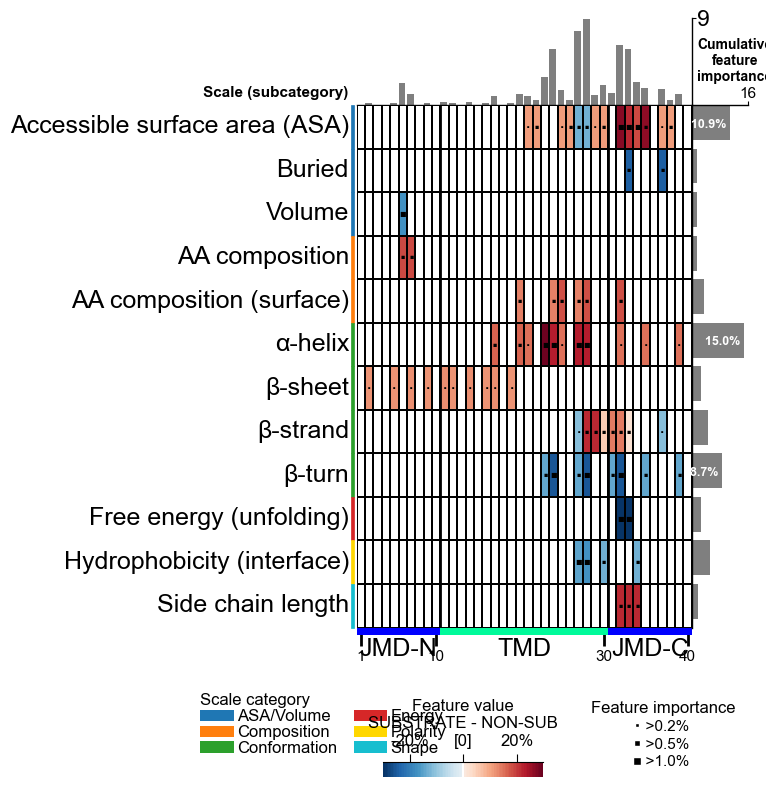

In [5]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, optimization="fast",
                                         top_n=25, plot=True,
                                         name_test="SUBSTRATE", name_ref="NON-SUB",
                                         random_state=42, n_jobs=1)

plt.tight_layout()
plt.show()